In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import os

client   = bigquery.Client(project='mimic-iv-project-490314')
df_cohort = pd.read_parquet('../data/cohort.parquet')
stay_ids  = df_cohort['stay_id'].tolist()

print(f"✓ Cohorte chargée : {len(df_cohort):,} séjours")
print(f"✓ stay_ids prêts  : {len(stay_ids):,}")

c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\auth\_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


✓ Cohorte chargée : 59,260 séjours
✓ stay_ids prêts  : 59,260


In [2]:
# ============================================================
# BLOC 1 — Vitales (chartevents) — version corrigée
# ============================================================
from google.cloud import bigquery

query_vitals = """
WITH cohort AS (
    SELECT i.stay_id, i.intime, i.outtime
    FROM `physionet-data.mimiciv_3_1_icu.icustays` i
    WHERE i.stay_id IN UNNEST(@stay_ids)
),

raw AS (
    SELECT
        c.stay_id,
        ce.charttime,
        CASE
            WHEN ce.itemid IN (223761, 223762) THEN 'temp'
            WHEN ce.itemid IN (220052, 220181) THEN 'map'
            WHEN ce.itemid = 220045            THEN 'hr'
            WHEN ce.itemid = 220210            THEN 'rr'
            WHEN ce.itemid = 220179            THEN 'sbp'
            WHEN ce.itemid = 220180            THEN 'dbp'
            WHEN ce.itemid = 220277            THEN 'spo2'
            WHEN ce.itemid = 220739            THEN 'gcs'
        END AS vital,
        CASE
            WHEN ce.itemid = 223761 THEN (ce.valuenum - 32) * 5.0 / 9.0
            ELSE ce.valuenum
        END AS val
    FROM cohort c
    JOIN `physionet-data.mimiciv_3_1_icu.chartevents` ce
        ON  ce.stay_id   = c.stay_id
        AND ce.charttime BETWEEN c.intime AND c.outtime
        AND ce.valuenum  IS NOT NULL
    WHERE ce.itemid IN (
        220045, 220210, 220179, 220180,
        220052, 220181, 220277,
        223761, 223762, 220739
    )
),

ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY stay_id, vital
            ORDER BY charttime DESC
        ) AS rn
    FROM raw
),

agg AS (
    SELECT
        stay_id,
        vital,
        MAX(CASE WHEN rn = 1 THEN val END) AS val_last,
        MAX(val)  AS val_max,
        MIN(val)  AS val_min,
        COUNT(*)  AS val_count
    FROM ranked
    GROUP BY stay_id, vital
)

SELECT
    stay_id,
    MAX(CASE WHEN vital='hr'   THEN val_last  END) AS hr_last,
    MAX(CASE WHEN vital='hr'   THEN val_max   END) AS hr_max,
    MAX(CASE WHEN vital='hr'   THEN val_min   END) AS hr_min,
    MAX(CASE WHEN vital='hr'   THEN val_count END) AS hr_count,

    MAX(CASE WHEN vital='rr'   THEN val_last  END) AS rr_last,
    MAX(CASE WHEN vital='rr'   THEN val_max   END) AS rr_max,
    MAX(CASE WHEN vital='rr'   THEN val_min   END) AS rr_min,

    MAX(CASE WHEN vital='sbp'  THEN val_last  END) AS sbp_last,
    MAX(CASE WHEN vital='sbp'  THEN val_max   END) AS sbp_max,
    MAX(CASE WHEN vital='sbp'  THEN val_min   END) AS sbp_min,

    MAX(CASE WHEN vital='dbp'  THEN val_last  END) AS dbp_last,
    MAX(CASE WHEN vital='dbp'  THEN val_max   END) AS dbp_max,
    MAX(CASE WHEN vital='dbp'  THEN val_min   END) AS dbp_min,

    MAX(CASE WHEN vital='map'  THEN val_last  END) AS map_last,
    MAX(CASE WHEN vital='map'  THEN val_max   END) AS map_max,
    MAX(CASE WHEN vital='map'  THEN val_min   END) AS map_min,

    MAX(CASE WHEN vital='spo2' THEN val_last  END) AS spo2_last,
    MAX(CASE WHEN vital='spo2' THEN val_min   END) AS spo2_min,

    MAX(CASE WHEN vital='temp' THEN val_last  END) AS temp_last,
    MAX(CASE WHEN vital='temp' THEN val_max   END) AS temp_max,
    MAX(CASE WHEN vital='temp' THEN val_min   END) AS temp_min,

    MAX(CASE WHEN vital='gcs'  THEN val_last  END) AS gcs_last,
    MAX(CASE WHEN vital='gcs'  THEN val_min   END) AS gcs_min

FROM agg
GROUP BY stay_id
"""

print("Lancement Bloc 1 — Vitales (5-10 min)...")
job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter('stay_ids', 'INT64', stay_ids)
    ]
)
df_vitals = client.query(query_vitals, job_config=job_config).to_dataframe()

print(f"✓ {len(df_vitals):,} séjours | {df_vitals.shape[1]} colonnes")
print("\nCouverture :")
for col in ['hr_last','rr_last','sbp_last','map_last','spo2_last','temp_last','gcs_last']:
    pct = df_vitals[col].notna().mean() * 100
    print(f"  {col:<12} : {pct:.1f}%")

Lancement Bloc 1 — Vitales (5-10 min)...


c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


✓ 59,260 séjours | 24 colonnes

Couverture :
  hr_last      : 100.0%
  rr_last      : 99.9%
  sbp_last     : 99.4%
  map_last     : 100.0%
  spo2_last    : 100.0%
  temp_last    : 99.8%
  gcs_last     : 100.0%


In [3]:
# Sauvegarde Bloc 1
df_vitals.to_parquet('../data/features_vitals.parquet', index=False)
print("✓ Bloc 1 sauvegardé")

✓ Bloc 1 sauvegardé


In [4]:
# ============================================================
# BLOC 2 — Biologies routine (labevents)
# Disponibilité > 85% : médiane simple
# ============================================================
query_labs = """
WITH cohort AS (
    SELECT i.stay_id, i.subject_id, i.hadm_id, i.intime, i.outtime
    FROM `physionet-data.mimiciv_3_1_icu.icustays` i
    WHERE i.stay_id IN UNNEST(@stay_ids)
),

raw AS (
    SELECT
        c.stay_id,
        l.charttime,
        CASE
            WHEN l.itemid = 50912 THEN 'creatinine'
            WHEN l.itemid = 51006 THEN 'bun'
            WHEN l.itemid = 50983 THEN 'sodium'
            WHEN l.itemid = 50971 THEN 'potassium'
            WHEN l.itemid = 50882 THEN 'bicarbonate'
            WHEN l.itemid = 50902 THEN 'chloride'
            WHEN l.itemid = 51222 THEN 'hemoglobin'
            WHEN l.itemid = 51265 THEN 'platelets'
            WHEN l.itemid = 51301 THEN 'wbc'
            WHEN l.itemid = 51237 THEN 'inr'
        END AS lab,
        l.valuenum AS val
    FROM cohort c
    JOIN `physionet-data.mimiciv_3_1_hosp.labevents` l
        ON  l.subject_id = c.subject_id
        AND l.hadm_id    = c.hadm_id
        AND l.charttime  BETWEEN c.intime AND c.outtime
        AND l.valuenum   IS NOT NULL
        AND l.valuenum   > 0
    WHERE l.itemid IN (
        50912, 51006, 50983, 50971, 50882,
        50902, 51222, 51265, 51301, 51237
    )
),

ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY stay_id, lab
            ORDER BY charttime DESC
        ) AS rn
    FROM raw
),

agg AS (
    SELECT
        stay_id, lab,
        MAX(CASE WHEN rn = 1 THEN val END) AS val_last,
        MAX(val) AS val_max,
        MIN(val) AS val_min
    FROM ranked
    GROUP BY stay_id, lab
)

SELECT
    stay_id,

    MAX(CASE WHEN lab='creatinine'  THEN val_last END) AS creatinine_last,
    MAX(CASE WHEN lab='creatinine'  THEN val_max  END) AS creatinine_max,

    MAX(CASE WHEN lab='bun'         THEN val_last END) AS bun_last,
    MAX(CASE WHEN lab='bun'         THEN val_max  END) AS bun_max,

    MAX(CASE WHEN lab='sodium'      THEN val_last END) AS sodium_last,
    MAX(CASE WHEN lab='sodium'      THEN val_max  END) AS sodium_max,
    MAX(CASE WHEN lab='sodium'      THEN val_min  END) AS sodium_min,

    MAX(CASE WHEN lab='potassium'   THEN val_last END) AS potassium_last,
    MAX(CASE WHEN lab='potassium'   THEN val_max  END) AS potassium_max,
    MAX(CASE WHEN lab='potassium'   THEN val_min  END) AS potassium_min,

    MAX(CASE WHEN lab='bicarbonate' THEN val_last END) AS bicarbonate_last,
    MAX(CASE WHEN lab='bicarbonate' THEN val_min  END) AS bicarbonate_min,

    MAX(CASE WHEN lab='chloride'    THEN val_last END) AS chloride_last,

    MAX(CASE WHEN lab='hemoglobin'  THEN val_last END) AS hemoglobin_last,
    MAX(CASE WHEN lab='hemoglobin'  THEN val_min  END) AS hemoglobin_min,

    MAX(CASE WHEN lab='platelets'   THEN val_last END) AS platelets_last,
    MAX(CASE WHEN lab='platelets'   THEN val_min  END) AS platelets_min,

    MAX(CASE WHEN lab='wbc'         THEN val_last END) AS wbc_last,
    MAX(CASE WHEN lab='wbc'         THEN val_max  END) AS wbc_max,

    MAX(CASE WHEN lab='inr'         THEN val_last END) AS inr_last,
    MAX(CASE WHEN lab='inr'         THEN val_max  END) AS inr_max

FROM agg
GROUP BY stay_id
"""

print("Lancement Bloc 2 — Biologies routine (3-5 min)...")
job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter('stay_ids', 'INT64', stay_ids)
    ]
)
df_labs = client.query(query_labs, job_config=job_config).to_dataframe()

print(f"✓ {len(df_labs):,} séjours | {df_labs.shape[1]} colonnes")
print("\nCouverture :")
for col in ['creatinine_last','bun_last','sodium_last','potassium_last',
            'hemoglobin_last','platelets_last','wbc_last','inr_last']:
    pct = df_labs[col].notna().mean() * 100
    print(f"  {col:<20} : {pct:.1f}%")

Lancement Bloc 2 — Biologies routine (3-5 min)...
✓ 59,018 séjours | 22 colonnes

Couverture :
  creatinine_last      : 99.9%
  bun_last             : 99.9%
  sodium_last          : 99.9%
  potassium_last       : 99.9%
  hemoglobin_last      : 99.9%
  platelets_last       : 99.9%
  wbc_last             : 99.9%
  inr_last             : 89.9%


In [5]:
# Sauvegarde Bloc 2
df_labs.to_parquet('../data/features_labs.parquet', index=False)
print("✓ Bloc 2 sauvegardé")

✓ Bloc 2 sauvegardé


In [6]:
# ============================================================
# BLOC 3 — Biologies MNAR (labevents)
# Lactate, Albumine, Bilirubine, ALT, AST, CK, Lipase
# + indicatrices has_X + feature composite n_missing_labs
# ============================================================
query_mnar = """
WITH cohort AS (
    SELECT i.stay_id, i.subject_id, i.hadm_id, i.intime, i.outtime
    FROM `physionet-data.mimiciv_3_1_icu.icustays` i
    WHERE i.stay_id IN UNNEST(@stay_ids)
),

raw AS (
    SELECT
        c.stay_id,
        l.charttime,
        CASE
            WHEN l.itemid = 50813 THEN 'lactate'
            WHEN l.itemid = 50862 THEN 'albumin'
            WHEN l.itemid = 50885 THEN 'bilirubin'
            WHEN l.itemid = 50861 THEN 'alt'
            WHEN l.itemid = 50878 THEN 'ast'
            WHEN l.itemid = 50911 THEN 'ck'
            WHEN l.itemid = 50956 THEN 'lipase'
        END AS lab,
        l.valuenum AS val
    FROM cohort c
    JOIN `physionet-data.mimiciv_3_1_hosp.labevents` l
        ON  l.subject_id = c.subject_id
        AND l.hadm_id    = c.hadm_id
        AND l.charttime  BETWEEN c.intime AND c.outtime
        AND l.valuenum   IS NOT NULL
        AND l.valuenum   >= 0
    WHERE l.itemid IN (50813, 50862, 50885, 50861, 50878, 50911, 50956)
),

ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY stay_id, lab
            ORDER BY charttime DESC
        ) AS rn
    FROM raw
),

agg AS (
    SELECT
        stay_id, lab,
        MAX(CASE WHEN rn = 1 THEN val END) AS val_last,
        MAX(val) AS val_max
    FROM ranked
    GROUP BY stay_id, lab
),

pivoted AS (
    SELECT
        stay_id,
        MAX(CASE WHEN lab='lactate'   THEN val_last END) AS lactate_last,
        MAX(CASE WHEN lab='lactate'   THEN val_max  END) AS lactate_max,
        MAX(CASE WHEN lab='albumin'   THEN val_last END) AS albumin_last,
        MAX(CASE WHEN lab='bilirubin' THEN val_last END) AS bilirubin_last,
        MAX(CASE WHEN lab='bilirubin' THEN val_max  END) AS bilirubin_max,
        MAX(CASE WHEN lab='alt'       THEN val_last END) AS alt_last,
        MAX(CASE WHEN lab='alt'       THEN val_max  END) AS alt_max,
        MAX(CASE WHEN lab='ast'       THEN val_last END) AS ast_last,
        MAX(CASE WHEN lab='ast'       THEN val_max  END) AS ast_max,
        MAX(CASE WHEN lab='ck'        THEN val_last END) AS ck_last,
        MAX(CASE WHEN lab='ck'        THEN val_max  END) AS ck_max,
        MAX(CASE WHEN lab='lipase'    THEN val_last END) AS lipase_last,
        MAX(CASE WHEN lab='lipase'    THEN val_max  END) AS lipase_max
    FROM agg
    GROUP BY stay_id
)

-- Jointure avec tous les séjours pour générer les has_X même si valeur absente
SELECT
    c.stay_id,
    p.lactate_last,
    p.lactate_max,
    p.albumin_last,
    p.bilirubin_last,
    p.bilirubin_max,
    p.alt_last,
    p.alt_max,
    p.ast_last,
    p.ast_max,
    p.ck_last,
    p.ck_max,
    p.lipase_last,
    p.lipase_max,

    -- Indicatrices MNAR
    CASE WHEN p.lactate_last   IS NOT NULL THEN 1 ELSE 0 END AS has_lactate,
    CASE WHEN p.albumin_last   IS NOT NULL THEN 1 ELSE 0 END AS has_albumin,
    CASE WHEN p.bilirubin_last IS NOT NULL THEN 1 ELSE 0 END AS has_bilirubin,
    CASE WHEN p.alt_last       IS NOT NULL THEN 1 ELSE 0 END AS has_alt,
    CASE WHEN p.ast_last       IS NOT NULL THEN 1 ELSE 0 END AS has_ast,
    CASE WHEN p.ck_last        IS NOT NULL THEN 1 ELSE 0 END AS has_ck,
    CASE WHEN p.lipase_last    IS NOT NULL THEN 1 ELSE 0 END AS has_lipase,

    -- Feature composite n_missing_labs
    (CASE WHEN p.lactate_last   IS NULL THEN 1 ELSE 0 END +
     CASE WHEN p.albumin_last   IS NULL THEN 1 ELSE 0 END +
     CASE WHEN p.bilirubin_last IS NULL THEN 1 ELSE 0 END) AS n_missing_labs

FROM (SELECT DISTINCT stay_id FROM `physionet-data.mimiciv_3_1_icu.icustays`
      WHERE stay_id IN UNNEST(@stay_ids)) c
LEFT JOIN pivoted p ON p.stay_id = c.stay_id
"""

print("Lancement Bloc 3 — Biologies MNAR (3-5 min)...")
job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter('stay_ids', 'INT64', stay_ids)
    ]
)
df_mnar = client.query(query_mnar, job_config=job_config).to_dataframe()

print(f"✓ {len(df_mnar):,} séjours | {df_mnar.shape[1]} colonnes")
print("\nDisponibilité (taux de présence) :")
for col in ['has_lactate','has_albumin','has_bilirubin','has_alt','has_ast','has_ck','has_lipase']:
    pct = df_mnar[col].mean() * 100
    print(f"  {col:<18} : {pct:.1f}%")
print(f"\nn_missing_labs distribution :")
print(df_mnar['n_missing_labs'].value_counts().sort_index().to_string())

Lancement Bloc 3 — Biologies MNAR (3-5 min)...
✓ 59,260 séjours | 22 colonnes

Disponibilité (taux de présence) :
  has_lactate        : 62.0%
  has_albumin        : 36.7%
  has_bilirubin      : 50.5%
  has_alt            : 50.6%
  has_ast            : 51.1%
  has_ck             : 26.6%
  has_lipase         : 11.6%

n_missing_labs distribution :
n_missing_labs
0    14784
1    12432
2    19264
3    12780


In [7]:
# Sauvegarde Bloc 3
df_mnar.to_parquet('../data/features_mnar.parquet', index=False)
print("✓ Bloc 3 sauvegardé")

✓ Bloc 3 sauvegardé


In [8]:
# ============================================================
# BLOC 4 — Scores dérivés (version corrigée)
# ============================================================
query_scores = """
WITH cohort AS (
    SELECT i.stay_id, i.hadm_id
    FROM `physionet-data.mimiciv_3_1_icu.icustays` i
    WHERE i.stay_id IN UNNEST(@stay_ids)
),

-- SOFA J1 : première fenêtre 24h
sofa_j1 AS (
    SELECT stay_id, MIN(sofa_24hours) AS sofa_j1
    FROM `physionet-data.mimiciv_3_1_derived.sofa`
    WHERE stay_id IN UNNEST(@stay_ids)
      AND hr <= 24
      AND sofa_24hours IS NOT NULL
    GROUP BY stay_id
),

-- SOFA last : fenêtre avec hr maximum
sofa_last AS (
    SELECT stay_id, sofa_24hours AS sofa_last
    FROM (
        SELECT stay_id, sofa_24hours,
            ROW_NUMBER() OVER (
                PARTITION BY stay_id
                ORDER BY hr DESC
            ) AS rn
        FROM `physionet-data.mimiciv_3_1_derived.sofa`
        WHERE stay_id IN UNNEST(@stay_ids)
          AND sofa_24hours IS NOT NULL
    )
    WHERE rn = 1
),

sapsii AS (
    SELECT stay_id, sapsii
    FROM `physionet-data.mimiciv_3_1_derived.sapsii`
    WHERE stay_id IN UNNEST(@stay_ids)
),

charlson AS (
    SELECT hadm_id, charlson_comorbidity_index AS cci
    FROM `physionet-data.mimiciv_3_1_derived.charlson`
)

SELECT
    c.stay_id,
    j1.sofa_j1,
    sl.sofa_last,
    sl.sofa_last - j1.sofa_j1 AS delta_sofa,
    sa.sapsii,
    ch.cci AS charlson_cci

FROM cohort c
LEFT JOIN sofa_j1   j1 ON j1.stay_id = c.stay_id
LEFT JOIN sofa_last sl ON sl.stay_id = c.stay_id
LEFT JOIN sapsii    sa ON sa.stay_id = c.stay_id
LEFT JOIN charlson  ch ON ch.hadm_id = c.hadm_id
"""

print("Lancement Bloc 4 — Scores dérivés (1-2 min)...")
job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter('stay_ids', 'INT64', stay_ids)
    ]
)
df_scores = client.query(query_scores, job_config=job_config).to_dataframe()

print(f"✓ {len(df_scores):,} séjours | {df_scores.shape[1]} colonnes")
print("\nCouverture + stats :")
for col in ['sofa_j1','sofa_last','delta_sofa','sapsii','charlson_cci']:
    pct = df_scores[col].notna().mean() * 100
    med = df_scores[col].median()
    print(f"  {col:<16} : {pct:.1f}%  (median={med:.0f})")

Lancement Bloc 4 — Scores dérivés (1-2 min)...


c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


✓ 59,260 séjours | 6 colonnes

Couverture + stats :
  sofa_j1          : 100.0%  (median=1)
  sofa_last        : 100.0%  (median=2)
  delta_sofa       : 100.0%  (median=1)
  sapsii           : 100.0%  (median=33)
  charlson_cci     : 100.0%  (median=5)


In [9]:
# Sauvegarde Bloc 4
df_scores.to_parquet('../data/features_scores.parquet', index=False)
print("✓ Bloc 4 sauvegardé")

✓ Bloc 4 sauvegardé


In [10]:
# ============================================================
# BLOC 5 — Gazométrie (table dérivée bg)
# PaO2, PaCO2, pH, PaO2/FiO2 + indicatrices has_bg
# ============================================================
query_bg = """
WITH cohort AS (
    SELECT i.stay_id, i.subject_id, i.intime, i.outtime
    FROM `physionet-data.mimiciv_3_1_icu.icustays` i
    WHERE i.stay_id IN UNNEST(@stay_ids)
),

raw AS (
    SELECT
        c.stay_id,
        bg.charttime,
        bg.po2        AS pao2,
        bg.pco2       AS paco2,
        bg.ph,
        bg.pao2fio2ratio AS pf_ratio
    FROM cohort c
    JOIN `physionet-data.mimiciv_3_1_derived.bg` bg
        ON  bg.subject_id = c.subject_id
        AND bg.charttime  BETWEEN c.intime AND c.outtime
        AND bg.specimen   = 'ART.'
),

ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY stay_id ORDER BY charttime DESC
        ) AS rn
    FROM raw
),

agg AS (
    SELECT
        stay_id,
        MAX(CASE WHEN rn = 1 THEN pao2     END) AS pao2_last,
        MIN(pao2)                                AS pao2_min,
        MAX(CASE WHEN rn = 1 THEN paco2    END) AS paco2_last,
        MAX(paco2)                               AS paco2_max,
        MAX(CASE WHEN rn = 1 THEN ph       END) AS ph_last,
        MIN(ph)                                  AS ph_min,
        MAX(CASE WHEN rn = 1 THEN pf_ratio END) AS pf_ratio_last,
        MIN(pf_ratio)                            AS pf_ratio_min
    FROM ranked
    GROUP BY stay_id
)

SELECT
    c.stay_id,
    a.pao2_last,
    a.pao2_min,
    a.paco2_last,
    a.paco2_max,
    a.ph_last,
    a.ph_min,
    a.pf_ratio_last,
    a.pf_ratio_min,
    CASE WHEN a.pao2_last IS NOT NULL THEN 1 ELSE 0 END AS has_bg

FROM (SELECT DISTINCT stay_id FROM `physionet-data.mimiciv_3_1_icu.icustays`
      WHERE stay_id IN UNNEST(@stay_ids)) c
LEFT JOIN agg a ON a.stay_id = c.stay_id
"""

print("Lancement Bloc 5 — Gazométrie (2-3 min)...")
job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter('stay_ids', 'INT64', stay_ids)
    ]
)
df_bg = client.query(query_bg, job_config=job_config).to_dataframe()

print(f"✓ {len(df_bg):,} séjours | {df_bg.shape[1]} colonnes")
print(f"\n  has_bg      : {df_bg['has_bg'].mean()*100:.1f}%")
print(f"  pao2_last   : {df_bg['pao2_last'].notna().mean()*100:.1f}%")
print(f"  pf_ratio    : {df_bg['pf_ratio_last'].notna().mean()*100:.1f}%")
print(f"\n  PaO2/FiO2 median (si mesuré) : "
      f"{df_bg['pf_ratio_last'].median():.0f}")

Lancement Bloc 5 — Gazométrie (2-3 min)...


c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


✓ 59,260 séjours | 10 colonnes

  has_bg      : 48.0%
  pao2_last   : 48.0%
  pf_ratio    : 31.7%

  PaO2/FiO2 median (si mesuré) : 262


In [11]:
# Sauvegarde Bloc 5
df_bg.to_parquet('../data/features_bg.parquet', index=False)
print("✓ Bloc 5 sauvegardé")

✓ Bloc 5 sauvegardé


In [12]:
# ============================================================
# BLOC 6 — Traitements (inputevents)
# Variables binaires : has_vasopressor, has_sedative, etc.
# ============================================================
query_treatments = """
WITH cohort AS (
    SELECT i.stay_id, i.intime, i.outtime
    FROM `physionet-data.mimiciv_3_1_icu.icustays` i
    WHERE i.stay_id IN UNNEST(@stay_ids)
),

raw AS (
    SELECT
        c.stay_id,
        CASE
            WHEN inp.itemid IN (221906,221289,222315,221662) THEN 'vasopressor'
            WHEN inp.itemid IN (221794,221833)               THEN 'diuretic'
            WHEN inp.itemid IN (221744,221668,225942,222168,
                                225154,222011,221986)        THEN 'sedative'
            WHEN inp.itemid IN (225151,221828,222056)        THEN 'antihypertensive'
        END AS treatment,
        SUM(inp.amount) AS total_amount
    FROM cohort c
    JOIN `physionet-data.mimiciv_3_1_icu.inputevents` inp
        ON  inp.stay_id   = c.stay_id
        AND inp.starttime BETWEEN c.intime AND c.outtime
        AND inp.amount    > 0
    WHERE inp.itemid IN (
        -- Vasopresseurs
        221906, 221289, 222315, 221662,
        -- Diurétiques IV
        221794, 221833,
        -- Sédatifs
        221744, 221668, 225942, 222168, 225154, 222011, 221986,
        -- Antihypertenseurs IV
        225151, 221828, 222056
    )
    GROUP BY c.stay_id, treatment
),

pivoted AS (
    SELECT
        stay_id,
        MAX(CASE WHEN treatment='vasopressor'     THEN 1 ELSE 0 END) AS has_vasopressor,
        MAX(CASE WHEN treatment='diuretic'        THEN 1 ELSE 0 END) AS has_diuretic,
        MAX(CASE WHEN treatment='sedative'        THEN 1 ELSE 0 END) AS has_sedative,
        MAX(CASE WHEN treatment='antihypertensive'THEN 1 ELSE 0 END) AS has_antihypertensive
    FROM raw
    GROUP BY stay_id
)

SELECT
    c.stay_id,
    COALESCE(p.has_vasopressor,      0) AS has_vasopressor,
    COALESCE(p.has_diuretic,         0) AS has_diuretic,
    COALESCE(p.has_sedative,         0) AS has_sedative,
    COALESCE(p.has_antihypertensive, 0) AS has_antihypertensive

FROM (SELECT DISTINCT stay_id FROM `physionet-data.mimiciv_3_1_icu.icustays`
      WHERE stay_id IN UNNEST(@stay_ids)) c
LEFT JOIN pivoted p ON p.stay_id = c.stay_id
"""

print("Lancement Bloc 6 — Traitements (2-3 min)...")
job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter('stay_ids', 'INT64', stay_ids)
    ]
)
df_treatments = client.query(query_treatments, job_config=job_config).to_dataframe()

print(f"✓ {len(df_treatments):,} séjours | {df_treatments.shape[1]} colonnes")
print("\nPrévalence :")
for col in ['has_vasopressor','has_diuretic','has_sedative','has_antihypertensive']:
    pct = df_treatments[col].mean() * 100
    print(f"  {col:<22} : {pct:.1f}%")

Lancement Bloc 6 — Traitements (2-3 min)...


c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


✓ 59,260 séjours | 5 colonnes

Prévalence :
  has_vasopressor        : 18.3%
  has_diuretic           : 42.6%
  has_sedative           : 64.1%
  has_antihypertensive   : 21.4%


In [13]:
df_treatments.to_parquet('../data/features_treatments.parquet', index=False)
print("✓ Bloc 6 sauvegardé")

✓ Bloc 6 sauvegardé


In [14]:
# ============================================================
# BLOC 7 — Ventilation + Diurèse (outputevents)
# ============================================================
query_vent_urine = """
WITH cohort AS (
    SELECT i.stay_id, i.intime, i.outtime
    FROM `physionet-data.mimiciv_3_1_icu.icustays` i
    WHERE i.stay_id IN UNNEST(@stay_ids)
),

-- Ventilation mécanique
vent AS (
    SELECT
        c.stay_id,
        1 AS has_ventilation,
        SUM(TIMESTAMP_DIFF(
            LEAST(v.endtime, c.outtime),
            GREATEST(v.starttime, c.intime),
            HOUR
        )) AS vent_hours,
        -- Heures entre fin ventilation et sortie ICU
        MIN(TIMESTAMP_DIFF(c.outtime, v.endtime, HOUR)) AS hours_since_extubation
    FROM cohort c
    JOIN `physionet-data.mimiciv_3_1_derived.ventilation` v
        ON  v.stay_id     = c.stay_id
        AND v.ventilation_status = 'InvasiveVent'
        AND v.starttime  < c.outtime
        AND v.endtime    > c.intime
    GROUP BY c.stay_id
),

-- Diurèse : volume urinaire dernières 24h avant sortie
urine AS (
    SELECT
        c.stay_id,
        SUM(o.value) AS urine_24h
    FROM cohort c
    JOIN `physionet-data.mimiciv_3_1_icu.outputevents` o
        ON  o.stay_id  = c.stay_id
        AND o.charttime BETWEEN
            TIMESTAMP_SUB(c.outtime, INTERVAL 24 HOUR)
            AND c.outtime
        AND o.value > 0
    WHERE o.itemid IN (226559, 226560, 226561, 226557, 226558, 227489)
    GROUP BY c.stay_id
)

SELECT
    c.stay_id,
    COALESCE(v.has_ventilation,       0)    AS has_ventilation,
    COALESCE(v.vent_hours,            0)    AS vent_hours,
    v.hours_since_extubation,
    u.urine_24h,
    CASE WHEN u.urine_24h < 500 THEN 1 ELSE 0 END AS has_oliguria

FROM (SELECT DISTINCT stay_id FROM `physionet-data.mimiciv_3_1_icu.icustays`
      WHERE stay_id IN UNNEST(@stay_ids)) c
LEFT JOIN vent  v ON v.stay_id = c.stay_id
LEFT JOIN urine u ON u.stay_id = c.stay_id
"""

print("Lancement Bloc 7 — Ventilation + Diurèse (2-3 min)...")
job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter('stay_ids', 'INT64', stay_ids)
    ]
)
df_vent = client.query(query_vent_urine, job_config=job_config).to_dataframe()

print(f"✓ {len(df_vent):,} séjours | {df_vent.shape[1]} colonnes")
print("\nStats :")
print(f"  has_ventilation        : {df_vent['has_ventilation'].mean()*100:.1f}%")
print(f"  vent_hours median      : {df_vent[df_vent['vent_hours']>0]['vent_hours'].median():.0f}h")
print(f"  hours_since_extubation : {df_vent['hours_since_extubation'].notna().mean()*100:.1f}% renseigné")
print(f"  urine_24h coverage     : {df_vent['urine_24h'].notna().mean()*100:.1f}%")
print(f"  has_oliguria           : {df_vent['has_oliguria'].mean()*100:.1f}%")

Lancement Bloc 7 — Ventilation + Diurèse (2-3 min)...
✓ 59,260 séjours | 6 colonnes

Stats :
  has_ventilation        : 39.4%
  vent_hours median      : 20h
  hours_since_extubation : 39.4% renseigné
  urine_24h coverage     : 92.3%
  has_oliguria           : 5.9%


In [15]:
df_vent.to_parquet('../data/features_vent.parquet', index=False)
print("✓ Bloc 7 sauvegardé")

✓ Bloc 7 sauvegardé


In [16]:
# ============================================================
# BLOC 8 — Démographie + features contextuelles
# Déjà dans df_cohort — on extrait et renomme proprement
# ============================================================

df_demo = df_cohort[[
    'stay_id', 'subject_id', 'hadm_id',
    'age', 'from_ed', 'los_hours', 'los_days',
    'first_careunit', 'anchor_year_group',
    'readmit_7d', 'readmit_14d', 'readmit_30d'
]].copy()

# Encodage numérique de l'unité ICU
unit_map = {
    'Medical Intensive Care Unit (MICU)':               0,
    'Medical/Surgical Intensive Care Unit (MICU/SICU)': 1,
    'Cardiac Vascular Intensive Care Unit (CVICU)':     2,
    'Surgical Intensive Care Unit (SICU)':              3,
    'Coronary Care Unit (CCU)':                         4,
    'Trauma SICU (TSICU)':                              5,
    'Neuro Intermediate':                               6,
    'Neuro Surgical Intensive Care Unit (Neuro SICU)':  7,
}
df_demo['careunit_encoded'] = df_demo['first_careunit'].map(unit_map)

# LOS hospitalier (admission → sortie ICU)
df_demo['hospital_los_days'] = (
    df_cohort['outtime'] - df_cohort['admittime']
).dt.total_seconds() / 86400

print(f"✓ {len(df_demo):,} séjours | {df_demo.shape[1]} colonnes")
print(f"\n  age mean          : {df_demo['age'].mean():.1f}")
print(f"  los_days median   : {df_demo['los_days'].median():.1f}")
print(f"  from_ed           : {df_demo['from_ed'].mean()*100:.1f}%")
print(f"  hospital_los mean : {df_demo['hospital_los_days'].mean():.1f}j")

df_demo.to_parquet('../data/features_demo.parquet', index=False)
print("\n✓ Bloc 8 sauvegardé")

✓ 59,260 séjours | 14 colonnes

  age mean          : 62.8
  los_days median   : 2.2
  from_ed           : 37.4%
  hospital_los mean : 5.0j

✓ Bloc 8 sauvegardé


In [18]:
# ============================================================
# BLOC 9 — Features last-24h avant sortie ICU
# ============================================================

query_last24h = """
WITH cohort AS (
    SELECT i.stay_id, i.subject_id, i.intime, i.outtime
    FROM `physionet-data.mimiciv_3_1_icu.icustays` i
    WHERE i.stay_id IN UNNEST(@stay_ids)
),

vitals_last24h AS (
    SELECT
        c.stay_id,
        AVG(CASE WHEN ce.itemid = 220045 THEN ce.valuenum END) AS hr_last24h_mean,
        STDDEV(CASE WHEN ce.itemid = 220045 THEN ce.valuenum END) AS hr_last24h_std,
        COUNT(CASE WHEN ce.itemid = 220045 THEN 1 END)          AS hr_last24h_count,
        AVG(CASE WHEN ce.itemid = 220179 THEN ce.valuenum END)  AS sbp_last24h_mean,
        MIN(CASE WHEN ce.itemid = 220179 THEN ce.valuenum END)  AS sbp_last24h_min,
        MIN(CASE WHEN ce.itemid = 220277 THEN ce.valuenum END)  AS spo2_last24h_min,
        AVG(CASE WHEN ce.itemid = 220210 THEN ce.valuenum END)  AS rr_last24h_mean,
        COUNT(*) AS n_chartevents_last24h
    FROM cohort c
    JOIN `physionet-data.mimiciv_3_1_icu.chartevents` ce
        ON  ce.stay_id   = c.stay_id
        AND ce.valuenum  IS NOT NULL
        AND ce.charttime BETWEEN
            TIMESTAMP_SUB(c.outtime, INTERVAL 24 HOUR)
            AND c.outtime
        AND ce.itemid IN (220045, 220179, 220277, 220210)
    GROUP BY c.stay_id
),

vaso_last24h AS (
    SELECT
        c.stay_id,
        MAX(CASE WHEN inp.itemid IN (221906, 221289, 222315, 221662)
            THEN 1 ELSE 0 END) AS vaso_last24h_flag
    FROM cohort c
    LEFT JOIN `physionet-data.mimiciv_3_1_icu.inputevents` inp
        ON  inp.stay_id   = c.stay_id
        AND inp.starttime BETWEEN
            TIMESTAMP_SUB(c.outtime, INTERVAL 24 HOUR)
            AND c.outtime
        AND inp.amount > 0
        AND inp.itemid IN (221906, 221289, 222315, 221662)
    GROUP BY c.stay_id
),

prior_icu AS (
    SELECT
        c.stay_id,
        COUNT(i2.stay_id) AS n_prior_icu_admissions
    FROM cohort c
    LEFT JOIN `physionet-data.mimiciv_3_1_icu.icustays` i2
        ON  i2.subject_id = c.subject_id
        AND i2.intime     < c.intime
    GROUP BY c.stay_id
)

SELECT
    c.stay_id,
    v.hr_last24h_mean,
    v.hr_last24h_std,
    v.hr_last24h_count,
    v.sbp_last24h_mean,
    v.sbp_last24h_min,
    v.spo2_last24h_min,
    v.rr_last24h_mean,
    v.n_chartevents_last24h,
    COALESCE(va.vaso_last24h_flag, 0)      AS vaso_last24h_flag,
    COALESCE(p.n_prior_icu_admissions, 0)  AS n_prior_icu_admissions

FROM cohort c
LEFT JOIN vitals_last24h v  ON v.stay_id = c.stay_id
LEFT JOIN vaso_last24h   va ON va.stay_id = c.stay_id
LEFT JOIN prior_icu      p  ON p.stay_id  = c.stay_id
"""

print("Lancement Bloc 9 — Features last-24h (5-8 min)...")
job_config = bigquery.QueryJobConfig(
    query_parameters=[
        bigquery.ArrayQueryParameter('stay_ids', 'INT64', stay_ids)
    ]
)
df_last24h = client.query(query_last24h, job_config=job_config).to_dataframe()

print(f"✓ {len(df_last24h):,} séjours | {df_last24h.shape[1]} colonnes")
print("\nCouverture :")
for col in ['hr_last24h_mean', 'sbp_last24h_min', 'spo2_last24h_min',
            'rr_last24h_mean', 'vaso_last24h_flag', 'n_prior_icu_admissions']:
    if df_last24h[col].dtype == float:
        pct = df_last24h[col].notna().mean() * 100
        med = df_last24h[col].median()
        print(f"  {col:<28} : {pct:.1f}%  (median={med:.1f})")
    else:
        pct = (df_last24h[col] > 0).mean() * 100
        med = df_last24h[col].median()
        print(f"  {col:<28} : {pct:.1f}% positifs  (median={med:.0f})")

Lancement Bloc 9 — Features last-24h (5-8 min)...


c:\Users\yanis\OneDrive\Documents\mlh-icu-readmission\venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


✓ 59,260 séjours | 11 colonnes

Couverture :
  hr_last24h_mean              : 99.9%  (median=81.9)
  sbp_last24h_min              : 98.1%  (median=99.0)
  spo2_last24h_min             : 99.7%  (median=92.0)
  rr_last24h_mean              : 99.4%  (median=18.7)
  vaso_last24h_flag            : 3.0% positifs  (median=0)
  n_prior_icu_admissions       : 22.7% positifs  (median=0)


In [19]:
# Sauvegarde Bloc 9
df_last24h.to_parquet('../data/features_last24h.parquet', index=False)
print('OK Bloc 9 sauvegarde -> features_last24h.parquet')


OK Bloc 9 sauvegarde -> features_last24h.parquet


In [20]:
# ============================================================
# ASSEMBLAGE FINAL — Fusion de tous les blocs
# ============================================================

print("Assemblage des blocs...")

df_features = df_demo.copy()

for name, df_bloc in [
    ('vitals',     df_vitals),
    ('labs',       df_labs),
    ('mnar',       df_mnar),
    ('scores',     df_scores),
    ('bg',         df_bg),
    ('treatments', df_treatments),
    ('vent',       df_vent),
]:
    n_before = len(df_features)
    df_features = df_features.merge(df_bloc, on='stay_id', how='left')
    print(f"  + {name:<12} : {df_bloc.shape[1]-1} features ajoutées "
          f"| {len(df_features):,} séjours")

print(f"\n✓ Dataset final : {df_features.shape[0]:,} séjours × "
      f"{df_features.shape[1]} colonnes")

# Aperçu des manquants globaux
n_miss = df_features.isnull().sum()
pct_miss = (n_miss / len(df_features) * 100).round(1)
miss_summary = pct_miss[pct_miss > 0].sort_values(ascending=False)
print(f"\nVariables avec manquants ({len(miss_summary)}) :")
print(miss_summary.head(20).to_string())

# Sauvegarde
df_features.to_parquet('../data/features_all.parquet', index=False)
print(f"\n✓ Sauvegardé → data/features_all.parquet")

Assemblage des blocs...
  + vitals       : 23 features ajoutées | 59,260 séjours
  + labs         : 21 features ajoutées | 59,260 séjours
  + mnar         : 21 features ajoutées | 59,260 séjours
  + scores       : 5 features ajoutées | 59,260 séjours
  + bg           : 9 features ajoutées | 59,260 séjours
  + treatments   : 4 features ajoutées | 59,260 séjours
  + vent         : 5 features ajoutées | 59,260 séjours

✓ Dataset final : 59,260 séjours × 102 colonnes

Variables avec manquants (56) :
lipase_max                88.4
lipase_last               88.4
ck_max                    73.4
ck_last                   73.4
pf_ratio_last             68.3
albumin_last              63.3
hours_since_extubation    60.6
pf_ratio_min              59.8
paco2_max                 52.0
ph_last                   52.0
ph_min                    52.0
paco2_last                52.0
pao2_min                  52.0
pao2_last                 52.0
bilirubin_last            49.5
bilirubin_max             49.5
alt

In [21]:
# Vérification finale
print("=== RÉCAPITULATIF FEATURE ENGINEERING ===")
print(f"Séjours     : {df_features.shape[0]:,}")
print(f"Features    : {df_features.shape[1]}")
print(f"\nVariable cible :")
print(f"  readmit_7d  : {df_features['readmit_7d'].sum():,} positifs ({df_features['readmit_7d'].mean()*100:.1f}%)")
print(f"  readmit_14d : {df_features['readmit_14d'].sum():,} positifs ({df_features['readmit_14d'].mean()*100:.1f}%)")
print(f"  readmit_30d : {df_features['readmit_30d'].sum():,} positifs ({df_features['readmit_30d'].mean()*100:.1f}%)")
print(f"\nColonnes disponibles :")
print([c for c in df_features.columns])

=== RÉCAPITULATIF FEATURE ENGINEERING ===
Séjours     : 59,260
Features    : 102

Variable cible :
  readmit_7d  : 3,144 positifs (5.3%)
  readmit_14d : 3,709 positifs (6.3%)
  readmit_30d : 3,922 positifs (6.6%)

Colonnes disponibles :
['stay_id', 'subject_id', 'hadm_id', 'age', 'from_ed', 'los_hours', 'los_days', 'first_careunit', 'anchor_year_group', 'readmit_7d', 'readmit_14d', 'readmit_30d', 'careunit_encoded', 'hospital_los_days', 'hr_last', 'hr_max', 'hr_min', 'hr_count', 'rr_last', 'rr_max', 'rr_min', 'sbp_last', 'sbp_max', 'sbp_min', 'dbp_last', 'dbp_max', 'dbp_min', 'map_last', 'map_max', 'map_min', 'spo2_last', 'spo2_min', 'temp_last', 'temp_max', 'temp_min', 'gcs_last', 'gcs_min', 'creatinine_last', 'creatinine_max', 'bun_last', 'bun_max', 'sodium_last', 'sodium_max', 'sodium_min', 'potassium_last', 'potassium_max', 'potassium_min', 'bicarbonate_last', 'bicarbonate_min', 'chloride_last', 'hemoglobin_last', 'hemoglobin_min', 'platelets_last', 'platelets_min', 'wbc_last', 'wb

C:\Users\yanis\AppData\Local\Temp\ipykernel_13088\155717253.py:146: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


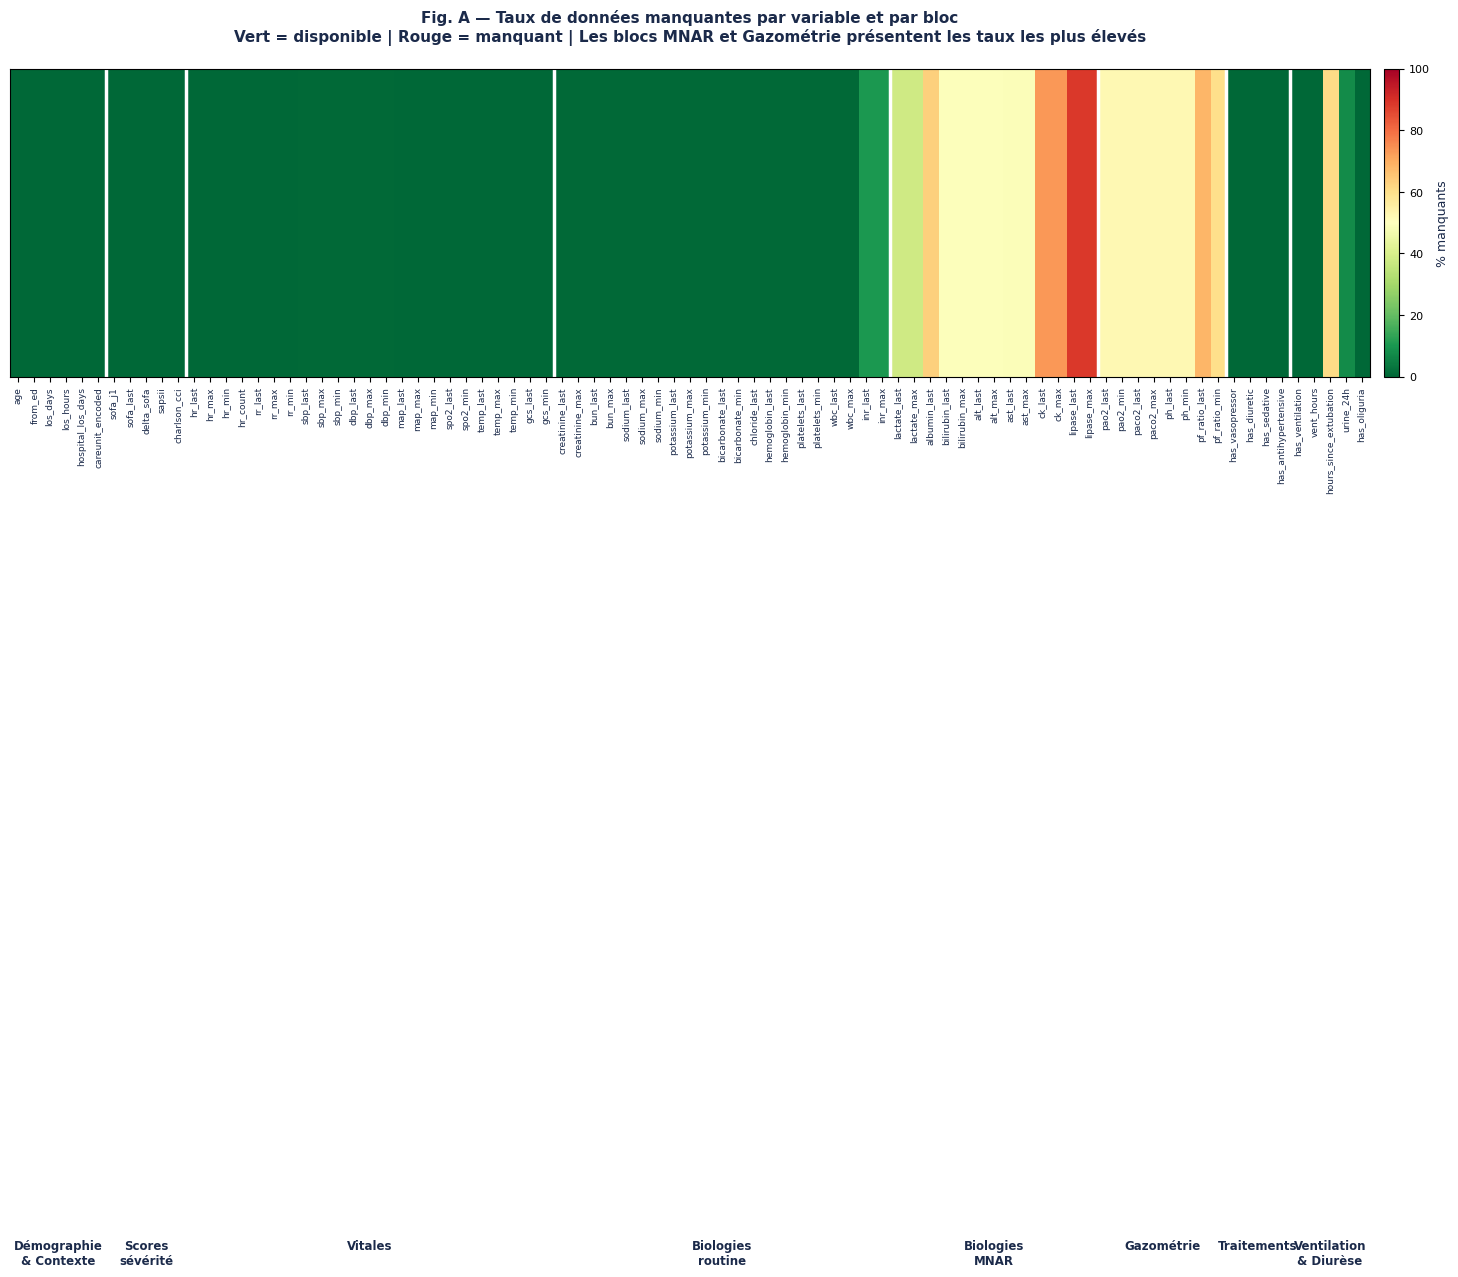

✓ Fig A sauvegardée


ValueError: list.index(x): x not in list

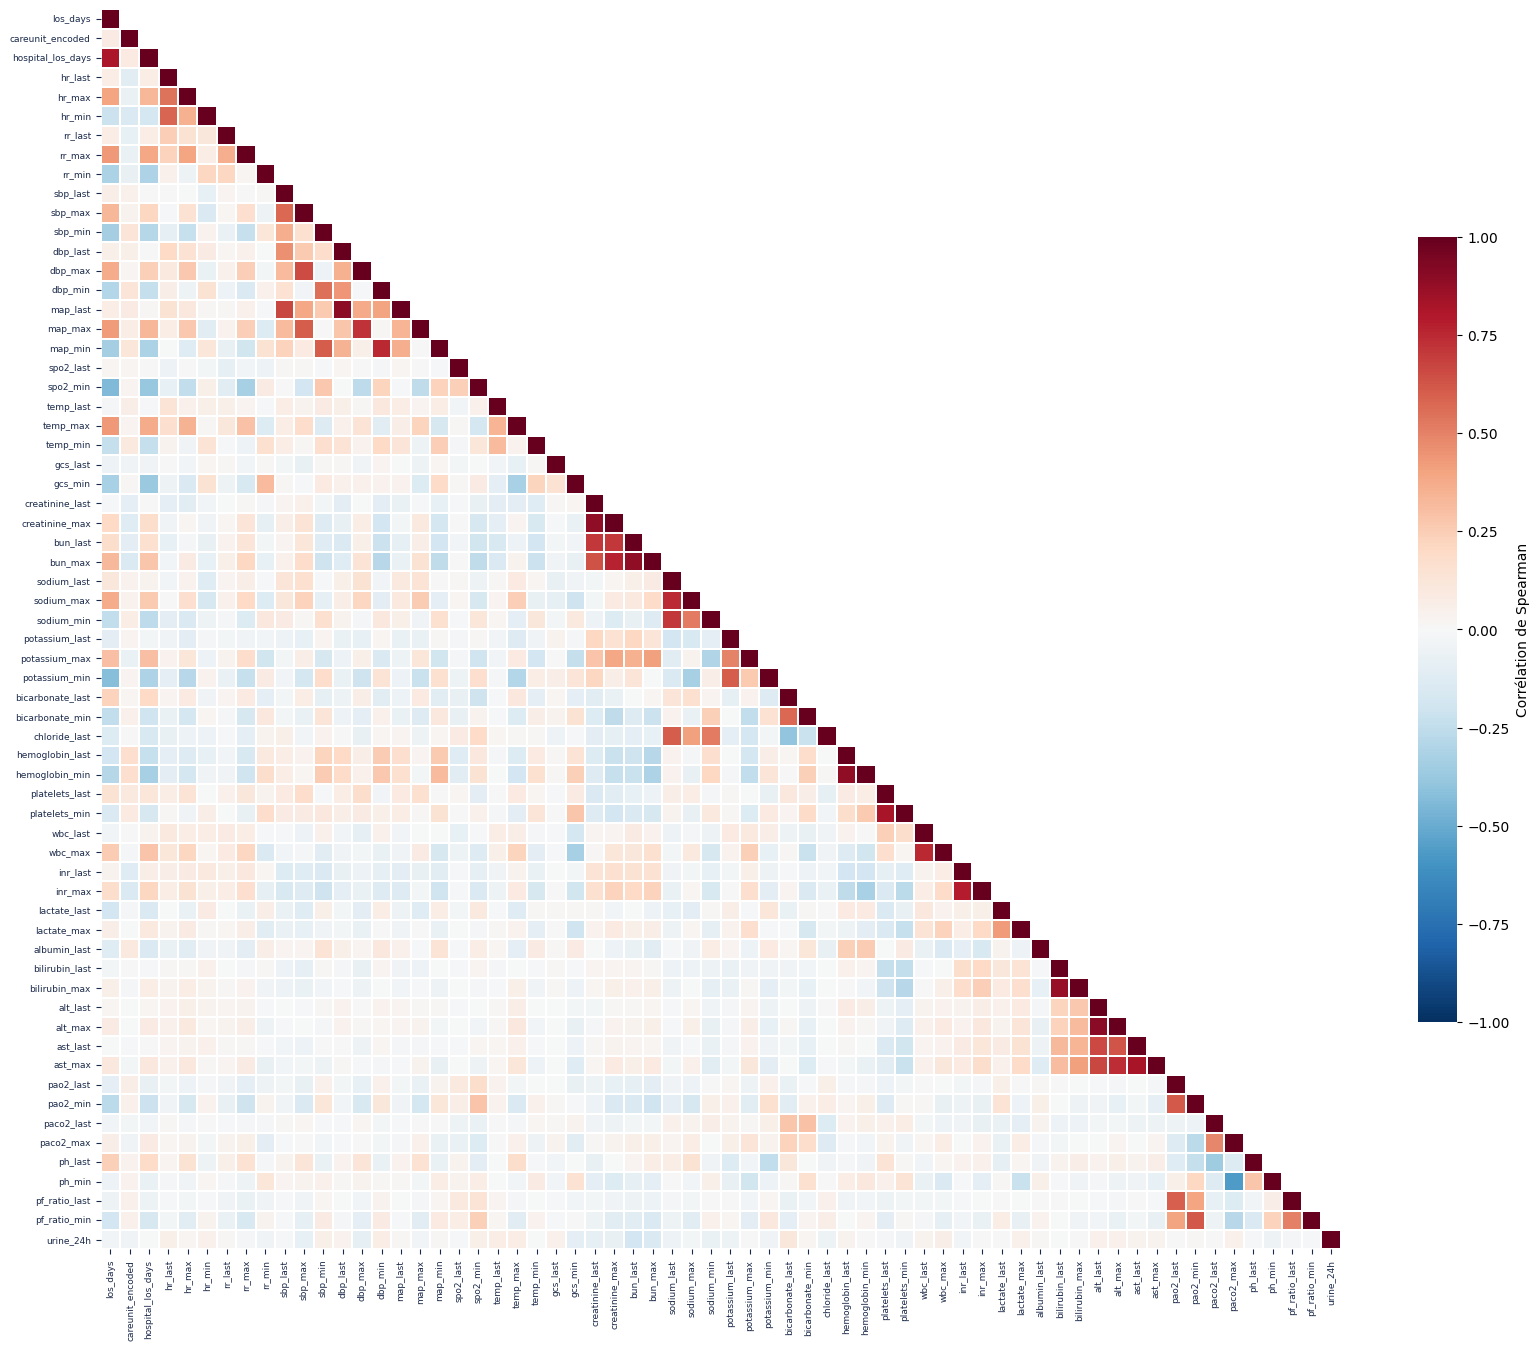

In [22]:
# ============================================================
# FIGURES FEATURE ENGINEERING — Fig A et Fig C
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
import os

os.makedirs('../figures', exist_ok=True)

NAVY  = '#1B2A4A'
BLUE  = '#2563EB'
TEAL  = '#0D9488'
RED   = '#DC2626'
LGRAY = '#F3F4F6'
GRAY  = '#6B7280'

# ── Colonnes à exclure de l'analyse features ─────────────
META_COLS = ['stay_id','subject_id','hadm_id','first_careunit',
             'anchor_year_group','readmit_7d','readmit_14d','readmit_30d']
IND_COLS  = [c for c in df_features.columns if c.startswith('has_')]

# Colonnes numériques features uniquement
feat_cols = [c for c in df_features.columns
             if c not in META_COLS
             and c not in IND_COLS
             and df_features[c].dtype in ['float64','int64','float32','int32']]

df_feat = df_features[feat_cols].copy()

# ══════════════════════════════════════════════════════════
# FIG A — Heatmap des données manquantes par bloc
# ══════════════════════════════════════════════════════════

# Blocs de variables
blocs = {
    'Démographie\n& Contexte': [
        'age','from_ed','los_days','los_hours',
        'hospital_los_days','careunit_encoded'
    ],
    'Scores\nsévérité': [
        'sofa_j1','sofa_last','delta_sofa','sapsii','charlson_cci'
    ],
    'Vitales': [
        'hr_last','hr_max','hr_min','hr_count',
        'rr_last','rr_max','rr_min',
        'sbp_last','sbp_max','sbp_min',
        'dbp_last','dbp_max','dbp_min',
        'map_last','map_max','map_min',
        'spo2_last','spo2_min',
        'temp_last','temp_max','temp_min',
        'gcs_last','gcs_min'
    ],
    'Biologies\nroutine': [
        'creatinine_last','creatinine_max',
        'bun_last','bun_max',
        'sodium_last','sodium_max','sodium_min',
        'potassium_last','potassium_max','potassium_min',
        'bicarbonate_last','bicarbonate_min',
        'chloride_last',
        'hemoglobin_last','hemoglobin_min',
        'platelets_last','platelets_min',
        'wbc_last','wbc_max',
        'inr_last','inr_max'
    ],
    'Biologies\nMNAR': [
        'lactate_last','lactate_max',
        'albumin_last',
        'bilirubin_last','bilirubin_max',
        'alt_last','alt_max',
        'ast_last','ast_max',
        'ck_last','ck_max',
        'lipase_last','lipase_max'
    ],
    'Gazométrie': [
        'pao2_last','pao2_min',
        'paco2_last','paco2_max',
        'ph_last','ph_min',
        'pf_ratio_last','pf_ratio_min'
    ],
    'Traitements': [
        'has_vasopressor','has_diuretic',
        'has_sedative','has_antihypertensive'
    ],
    'Ventilation\n& Diurèse': [
        'has_ventilation','vent_hours',
        'hours_since_extubation',
        'urine_24h','has_oliguria'
    ],
}

# Calcul taux de manquants par variable
pct_missing = df_features.isnull().mean() * 100

# Construction de la matrice pour le heatmap
all_vars = []
bloc_labels = []
bloc_sizes  = []
for bloc_name, vars_list in blocs.items():
    existing = [v for v in vars_list if v in df_features.columns]
    all_vars.extend(existing)
    bloc_labels.append(bloc_name)
    bloc_sizes.append(len(existing))

miss_vals = pct_missing[all_vars].values.reshape(1, -1)

fig, ax = plt.subplots(figsize=(18, 4))
fig.patch.set_facecolor('white')

im = ax.imshow(miss_vals, aspect='auto',
               cmap='RdYlGn_r', vmin=0, vmax=100)

# Labels variables
ax.set_xticks(range(len(all_vars)))
ax.set_xticklabels(all_vars, rotation=90, fontsize=6.5, color=NAVY)
ax.set_yticks([])

# Séparateurs de blocs + labels
x_pos = 0
for i, (bloc_name, size) in enumerate(zip(bloc_labels, bloc_sizes)):
    # Ligne verticale
    if i > 0:
        ax.axvline(x=x_pos - 0.5, color='white', linewidth=2.5)
    # Label bloc centré
    ax.text(x_pos + size/2 - 0.5, -2.8, bloc_name,
            ha='center', va='top', fontsize=8.5,
            fontweight='bold', color=NAVY,
            transform=ax.get_xaxis_transform())
    x_pos += size

# Colorbar
cbar = plt.colorbar(im, ax=ax, orientation='vertical',
                    pad=0.01, fraction=0.015)
cbar.set_label('% manquants', fontsize=9, color=NAVY)
cbar.ax.tick_params(labelsize=8)

ax.set_title(
    'Fig. A — Taux de données manquantes par variable et par bloc\n'
    'Vert = disponible | Rouge = manquant | '
    'Les blocs MNAR et Gazométrie présentent les taux les plus élevés',
    fontsize=11, fontweight='bold', color=NAVY, pad=20
)

plt.tight_layout()
plt.savefig('../figures/figA_missing_heatmap.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Fig A sauvegardée")

# ══════════════════════════════════════════════════════════
# FIG C — Heatmap de corrélation des features numériques
# ══════════════════════════════════════════════════════════

# Sélection features numériques avec < 70% de manquants
feat_num = [c for c in feat_cols
            if pct_missing.get(c, 0) < 70
            and c not in ['los_hours']]  # doublon avec los_days

df_corr = df_features[feat_num].copy()

# Imputation temporaire par médiane pour le calcul de corrélation
df_corr_filled = df_corr.apply(lambda x: x.fillna(x.median()))

# Matrice de corrélation de Spearman
corr_matrix = df_corr_filled.corr(method='spearman')

# Masque triangle supérieur
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(20, 17))
fig.patch.set_facecolor('white')

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    center=0,
    ax=ax,
    square=True,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'shrink': 0.6, 'label': 'Corrélation de Spearman'},
    xticklabels=True,
    yticklabels=True,
    annot=False,
)

ax.tick_params(axis='x', labelsize=6.5, rotation=90, colors=NAVY)
ax.tick_params(axis='y', labelsize=6.5, rotation=0,  colors=NAVY)

# Encadrer les blocs corrélés connus
# SOFA/SAPS-II
ax.add_patch(plt.Rectangle(
    (feat_num.index('sofa_j1'), feat_num.index('sofa_j1')),
    3, 3, fill=False, edgecolor=RED, lw=2.5, label='Scores sévérité'
))

ax.set_title(
    'Fig. C — Matrice de corrélations de Spearman entre features numériques\n'
    'Les blocs rouge indiquent les groupes de variables fortement corrélées '
    '→ justifie la pénalisation L1 (Lasso) pour la régression logistique',
    fontsize=11, fontweight='bold', color=NAVY, pad=12
)

plt.tight_layout()
plt.savefig('../figures/figC_correlation_matrix.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Fig C sauvegardée")